In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path
import pandas as pd

# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"



In [20]:

data_gap = pd.read_excel(DADOS/"gap.xlsx", header=2)
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano = gap_ano.set_index('Quarterly')
gap_ano.index.name = 'Year'
#Queremos apenas a partir do ano de 1993
gap_ano = gap_ano.loc[1993:2019]
gap_ano = gap_ano.reset_index()
gap_ano.head()

C:\Users\tgu12\AppData\Local\Temp\ipykernel_14420\1821887866.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)


,Year,Output gap
0,1993,-0.920757
1,1994,-1.145398
2,1995,-0.637239
3,1996,0.251554
4,1997,-0.714214


In [17]:
tx_juros = pd.read_excel(DADOS/"natural_interest_rate_japan.xlsx",header = 2)
tx_juros = tx_juros[["Unnamed: 2", "Goy and Iwasaki (2024)"]]

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
tx_n_y = tx_juros[tx_juros['Unnamed: 2'].str.contains('Q4$', na = False)]
tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
# 1. Renomeia as colunas corretamente usando o método .rename()
tx_n_y = tx_n_y.rename(columns={
    'Unnamed: 2': 'Year',
    'Goy and Iwasaki (2024)': 'Natural interest rate'
})

# 2. Transforma os anos no novo índice do DataFrame
tx_n_y["Year"].astype(int)


tx_n_y.head()

C:\Users\tgu12\AppData\Local\Temp\ipykernel_14420\2816863065.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)


,Year,Natural interest rate
3,1992,NaN
7,1993,0.885443
11,1994,0.677270
15,1995,0.210731
19,1996,0.044659


In [8]:
#Tratando os dados e montando dataframe
interest_data = pd.read_csv(DADOS/"taxa_de_juros_JPN_praticada.csv",skiprows=4)
interest_data_JPN  = interest_data[interest_data['Country Code'] == 'JPN']
# Remove as colunas especificadas 
japao_filtrado = interest_data_JPN.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code','Country Name'])
# 2. Remove colunaque comece com 'Unnamed'
colunas_validas = [col for col in japao_filtrado.columns if not col.startswith('Unnamed:')]
japao_limpo = japao_filtrado[colunas_validas]
# Transforma em um data frame com duas colunas sendo elas ano e taxa de juros
japao_int_rate = japao_limpo.melt(var_name='Year', value_name='Taxa de juros real')

# Remove todas as linhas onde a coluna 'Taxa de juros' possui NaN
japao_final = japao_int_rate.dropna(subset=['Taxa de juros real']).reset_index(drop=True)
japao_final["Year"] = japao_final['Year'].astype(int)

japao_final.head()

,Year,Taxa de juros real
0,1993,4.312358
1,1994,3.939249
2,1995,4.050495
3,1996,3.117255
4,1997,1.934613


_Gerando o gráfico_


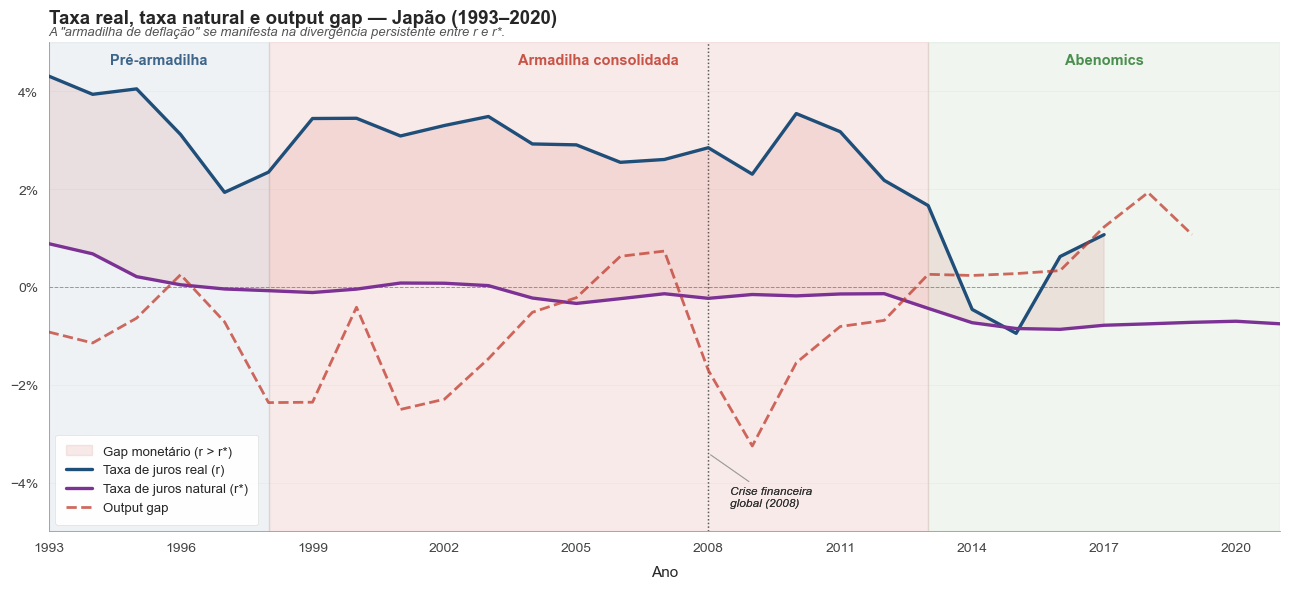

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Estilo geral
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


japao_final['Year'] = japao_final['Year'].astype(int)
tx_n_y['Year']      = tx_n_y['Year'].astype(int)
gap_ano['Year']     = gap_ano['Year'].astype(int)

# Paleta 
COR_REAL    = '#1f4e79'  
COR_NATURAL = '#7b3294'   
COR_GAP     = '#c0392b'   

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Sombreamento dos três períodos
ax.axvspan(1993, 1998, alpha=0.07, color=COR_REAL,    zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,     zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32',   zorder=0)

# Limites e rótulos dos períodos
ax.set_ylim(-5, 5)
ax.set_xlim(1993, 2021)

y_label = 4.55
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color=COR_REAL, weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

# Linha do zero
ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Gap monetário (área entre real e natural quando r > r*)
merged = japao_final.merge(tx_n_y, on='Year', how='inner')
ax.fill_between(merged['Year'],
                merged['Taxa de juros real'],
                merged['Natural interest rate'],
                where=(merged['Taxa de juros real'] > merged['Natural interest rate']),
                color=COR_GAP, alpha=0.10, interpolate=True, zorder=2,
                label='Gap monetário (r > r*)')

# Linhas principais — sem marcadores
sns.lineplot(data=japao_final, x='Year', y='Taxa de juros real',
             label='Taxa de juros real (r)',
             linewidth=2.4, color=COR_REAL, ax=ax, zorder=3)
sns.lineplot(data=tx_n_y, x='Year', y='Natural interest rate',
             label='Taxa de juros natural (r*)',
             linewidth=2.4, color=COR_NATURAL, ax=ax, zorder=3)
sns.lineplot(data=gap_ano, x='Year', y='Output gap',
             label='Output gap',
             linewidth=2.0, color=COR_GAP, alpha=0.75,
             linestyle='--', ax=ax, zorder=3)

# Eixo Y em formato de porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Eixo X com mais ticks
ax.set_xticks(range(1993, 2022, 3))

# Labels e título
ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Taxa real, taxa natural e output gap — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

# Subtítulo descritivo (opcional, mas dá contexto)
ax.text(0.0, 1.015,
        'A "armadilha de deflação" se manifesta na divergência persistente entre r e r*.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

# Legenda mais limpa
legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

# Grid sutil só no Y
ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

# Spines limpos
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

# Ticks discretos
ax.tick_params(colors='#444', length=4, width=0.6)

# Marcador do evento — crise financeira global de 2008
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -3.4), xytext=(2008.5, -4.3),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

plt.tight_layout()
plt.savefig(FIGURAS/'juros_e_gap_japao.png', dpi=200,
            bbox_inches='tight', facecolor='white')

# Marcador do evento — crise financeira global de 2008
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -3.4), xytext=(2008.5, -4.3),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))
plt.show()